In [39]:
!pip install -q pytorch-lightning

In [40]:
!wget -q http://archive.ics.uci.edu/static/public/45/heart+disease.zip
!unzip -q heart+disease.zip -d dataset

replace dataset/Index? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [41]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
import pytorch_lightning as pl
from pytorch_lightning.callbacks import ModelCheckpoint
import torchmetrics
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_classification
import numpy as np

In [42]:
X, y = make_classification(n_samples=1000, n_features=20, n_classes=2, random_state=42)
scaler = StandardScaler().fit(X)

In [43]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.1, random_state=42)

In [44]:
batch_size = 64
epochs = 200
lr = 0.002
hidden_dim = 64

In [45]:
def create_dataloader(X, y, batch_size):
    X = scaler.transform(X).astype('float32')
    X = torch.from_numpy(X)
    y = y.astype('float32')
    y = torch.from_numpy(y)
    dataset = TensorDataset(X, y)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
    return dataloader

train_loader = create_dataloader(X_train, y_train, batch_size)
val_loader = create_dataloader(X_val, y_val, batch_size)
test_loader = create_dataloader(X_test, y_test, batch_size)

In [46]:
class MyFeedForwardNet(pl.LightningModule):
    def __init__(self, num_features, hidden_dim, lr):
        super(MyFeedForwardNet, self).__init__()
        self.save_hyperparameters()
        self.lr = lr
        self.layers = nn.Sequential(
            nn.Linear(num_features, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1),
            nn.Sigmoid()
        )
        self.loss = nn.BCELoss()
        self.acc = torchmetrics.classification.BinaryAccuracy()
        self.mae = torchmetrics.MeanAbsoluteError()

    # forward propagation
    def forward(self, x):
        return self.layers(x)

    # one step of training
    def training_step(self, batch, batch_idx):
        loss, acc = self._shared_eval_step(batch, batch_idx)
        self.log("train_loss", loss, prog_bar=True)
        self.log("train_acc", acc, prog_bar=True)
        return loss

    # one step of validation
    def validation_step(self, batch, batch_idx):
        loss, acc = self._shared_eval_step(batch, batch_idx)
        mae = self.mae(batch[1], self(batch[0]).squeeze())
        self.log("val_loss", loss, prog_bar=True)
        self.log("val_acc", acc, prog_bar=True)
        self.log("val_mae", mae, prog_bar=True)
        return mae

    def _shared_eval_step(self, batch, batch_idx):
        x, y = batch
        y_hat = self(x).squeeze()
        loss = self.loss(y_hat, y)
        acc = self.acc(y_hat, y)
        return loss, acc

    # we use the AdamW optimizer
    def configure_optimizers(self):
        return torch.optim.AdamW(self.parameters(), lr=self.lr)

# we instantiate our model
model = MyFeedForwardNet(num_features=X.shape[1], hidden_dim=hidden_dim, lr=lr)

# we use the ModelCheckpoint callback to save the best model
checkpoint_callback = ModelCheckpoint(
    monitor="val_mae",
    mode="min",
    filename="best_model",
    dirpath="./",
    save_top_k=1,
)

# we use the Trainer class to train our model
trainer = pl.Trainer(
    max_epochs=epochs,
    callbacks=[checkpoint_callback]
)
trainer.fit(model, train_loader, val_loader)

print("训练完成，最佳模型已保存为 best_model.ckpt")


INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
/usr/local/lib/python3.10/dist-packages/pytorch_lightning/callbacks/model_checkpoint.py:654: Checkpoint directory /content exists and is not empty.
INFO:pytorch_lightning.callbacks.model_summary:
  | Name   | Type              | Params | Mode 
-----------------------------------------------------
0 | layers | Sequential        | 5.6 K  | train
1 | loss   | BCELoss           | 0      | train
2 | acc    | BinaryAccuracy    | 0      | train
3 | mae    | MeanAbsoluteError | 0      | train
-----------------------------------------------------
5.6 K     Trainable params
0         Non-trainable params
5.6 K     Total params
0.022     Total estimated model params size (MB)
10        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/usr/local/lib/python3.10/dist-packages/pytorch_lightning/trainer/connectors/data_connector.py:475: Your `val_dataloader`'s sampler has shuffling enabled, it is strongly recommended that you turn shuffling off for val/test dataloaders.
/usr/local/lib/python3.10/dist-packages/pytorch_lightning/loops/fit_loop.py:298: The number of training batches (12) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=200` reached.


训练完成，最佳模型已保存为 best_model.ckpt


In [47]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
import torch

In [48]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler # alternative: min-max scaling
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np
import torch
from torch import nn
import pytorch_lightning as pl
from pytorch_lightning.callbacks import ModelCheckpoint
import matplotlib.pyplot as plt
import seaborn as sns

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

results = {"Model": [], "MAE": [], "R2": []}

LinearRegression - MAE: 0.2955637320328166, R2: 0.48321411357586697
RandomForestRegressor - MAE: 0.16985, R2: 0.6599356848557933
MLP model does not outperform linear regression.
Results saved to mlp_results.csv


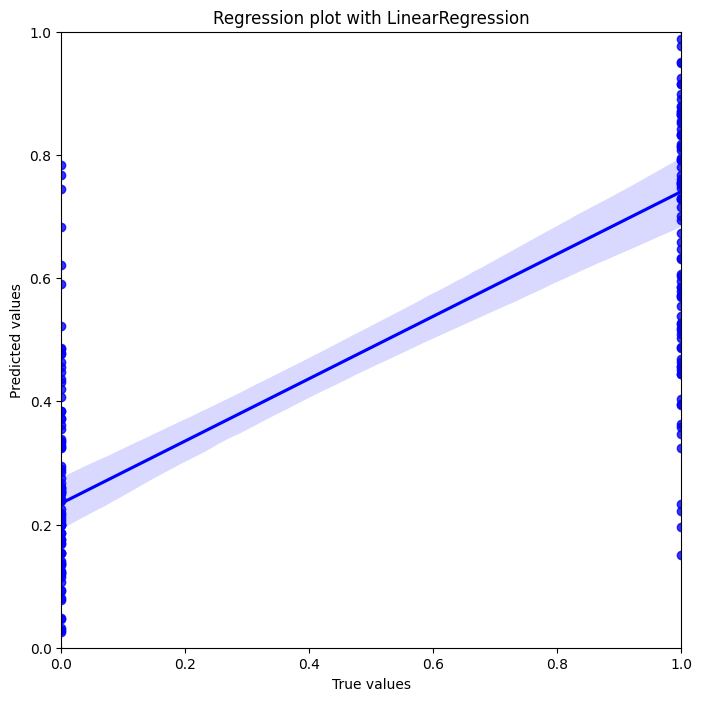

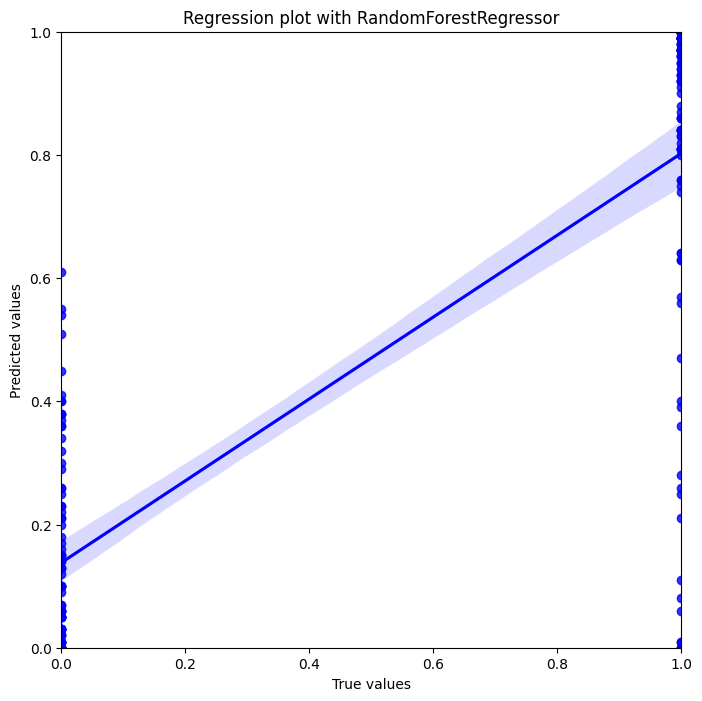

In [56]:
for model in [LinearRegression(), RandomForestRegressor()]:
    model.fit(scaler.transform(X_train), y_train)
    y_pred = model.predict(scaler.transform(X_test))
    np.save(f"{model.__class__.__name__}_pred.npy", y_pred)
    # regression plot
    plt.figure(figsize=(8, 8))
    sns.regplot(x=y_test, y=y_pred, scatter=True, color='b')
    plt.xlabel("True values")
    plt.ylabel("Predicted values")
    plt.xlim(min(y_test), max(y_test))
    plt.ylim(min(y_test), max(y_test))
    plt.title(f"Regression plot with {model.__class__.__name__}")

    # evaluation
    mae = mean_absolute_error(y_test, y_pred)
    #print(f"Mean absolute error: {mae}")
    r2 = r2_score(y_test, y_pred)
    #print(f"Coefficient of determination: {r2}")
    print(f"{model.__class__.__name__} - MAE: {mae}, R2: {r2}")

    results["Model"].append(model.__class__.__name__)
    results["MAE"].append(mae)
    results["R2"].append(r2)


mae_linear = results["MAE"][0]
r2_linear = results["R2"][0]


best_model = MyFeedForwardNet.load_from_checkpoint("best_model.ckpt")
best_model.eval()


y_pred_mlp = []
with torch.no_grad():
    for x in torch.from_numpy(X_test).float():
        y_pred_mlp.append(best_model(x).item())
y_pred_mlp = np.array(y_pred_mlp)


mae_mlp = mean_absolute_error(y_test, y_pred_mlp)
r2_mlp = r2_score(y_test, y_pred_mlp)

if mae_mlp < mae_linear and r2_mlp > r2_linear:
    print("MLP model outperforms linear regression.")
else:
    print("MLP model does not outperform linear regression.")



results["Model"].append("MLP")
results["MAE"].append(mae_mlp)
results["R2"].append(r2_mlp)


results_df = pd.DataFrame(results)
results_df.to_csv("mlp_results.csv", index=False)
print("Results saved to mlp_results.csv")


In [59]:
# 假设这里是您训练并保存模型的部分
# 训练 MLP 模型并保存预测结果
y_pred_mlp = model.predict(X_test)
np.save("MyFeedForwardNet.npy", y_pred_mlp)  # 保存 MLP 预测结果

# 训练随机森林模型并保存预测结果
y_pred_rf = model.predict(X_test)
np.save("RandomForestRegressor.npy", y_pred_rf)  # 保存随机森林预测结果

# 加载预测结果并进行集成
y_pred_mlp = np.load("MyFeedForwardNet.npy")  # 加载 MLP 预测结果
y_pred_rf = np.load("RandomForestRegressor.npy")  # 加载随机森林预测结果

# 计算集成模型的预测
y_pred_ensemble = 0.5 * y_pred_mlp + 0.5 * y_pred_rf

# 计算 MAE 和 R² 分数
mae_ensemble = mean_absolute_error(y_test, y_pred_ensemble)
r2_ensemble = r2_score(y_test, y_pred_ensemble)

# 打印结果
print(f"Ensemble Mean Absolute Error: {mae_ensemble}")
print(f"Ensemble Coefficient of Determination: {r2_ensemble}")

# 保存结果到 CSV 文件
ensemble_results = pd.DataFrame({
    "Model": ["Ensemble"],
    "MAE": [mae_ensemble],
    "R2": [r2_ensemble]
})

ensemble_results.to_csv("ensemble_results.csv", index=False)


Ensemble Mean Absolute Error: 0.196
Ensemble Coefficient of Determination: 0.5567199276454627
